# **Regression Analysis on CO2 Emissions Dataset**

Here we are performing regression analysis on a dataset containing vehicle specifications and their CO2 emissions. We apply Linear Regression, Ridge Regression, and Lasso Regression to predict CO2 emissions based on vehicle features.

In [1]:
# Importing all the necessary libraries and functions at once

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("co2.csv")

**Selecting relevant features and the target variable (CO2 Emissions)**

In [3]:
features = ['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)',
            'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)',
            'Fuel Consumption Comb (mpg)']
target = 'CO2 Emissions(g/km)'

X = df[features]
y = df[target]

In [4]:
## Data Preprocessing (Standardizing features to improve accuracy of model)

scaler = StandardScaler()
X = scaler.fit_transform(X)

**Splitting Dataset**

In [5]:
#We split the dataset into training (75%) and testing (25%) sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

### **Linear Regression Model**

In [6]:
#We train a Linear Regression model to predict CO2 emissions and evaluate its performance.

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)

print("Linear Regression Metrics:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

Linear Regression Metrics:
MAE: 11.53291088008849
MSE: 338.01646135474977
RMSE: 18.38522399522915
R2 Score: 0.9009096156787428


### **Optimized Linear Regression Model**

In [7]:
#We train a Linear Regression model with cross-validation to optimize performance.

lin_reg = LinearRegression()
scores = cross_val_score(lin_reg, X_train, y_train, cv=5, scoring='r2')
lin_reg.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)

print("Linear Regression Metrics:")
print("Cross-Validation R2 Score:", scores.mean())
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

Linear Regression Metrics:
Cross-Validation R2 Score: 0.9040782548728524
MAE: 11.53291088008849
MSE: 338.01646135474977
RMSE: 18.38522399522915
R2 Score: 0.9009096156787428


**We got a good score (accuracy) of 90%.**

### **Ridge Regression Model**

In [8]:
#We apply Ridge Regression, which includes L2 regularization to prevent overfitting.

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_ridge_pred = ridge.predict(X_test)

print("\nRidge Regression Metrics:")
print("MAE:", mean_absolute_error(y_test, y_ridge_pred))
print("MSE:", mean_squared_error(y_test, y_ridge_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_ridge_pred)))
print("R2 Score:", r2_score(y_test, y_ridge_pred))


Ridge Regression Metrics:
MAE: 11.53246723668198
MSE: 338.0295125319014
RMSE: 18.38557892838573
R2 Score: 0.9009057896930065


### **Optimized Ridge Regression Model**

In [9]:
#We tune the alpha parameter using GridSearchCV.

ridge_params = {'alpha': [0.1, 1.0, 10.0, 100.0]}
ridge = Ridge()
ridge_cv = GridSearchCV(ridge, ridge_params, cv=5, scoring='r2')
ridge_cv.fit(X_train, y_train)

best_ridge = ridge_cv.best_estimator_
y_ridge_pred = best_ridge.predict(X_test)

print("\nRidge Regression Metrics:")
print("Best Alpha:", ridge_cv.best_params_['alpha'])
print("MAE:", mean_absolute_error(y_test, y_ridge_pred))
print("MSE:", mean_squared_error(y_test, y_ridge_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_ridge_pred)))
print("R2 Score:", r2_score(y_test, y_ridge_pred))


Ridge Regression Metrics:
Best Alpha: 10.0
MAE: 11.531354455714347
MSE: 338.18787944183595
RMSE: 18.38988524819652
R2 Score: 0.9008593640310542


**No better results**

### **Lasso Regression Model**

In [10]:
#We apply Lasso Regression, which includes L1 regularization for feature selection.

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_lasso_pred = lasso.predict(X_test)

print("\nLasso Regression Metrics:")
print("MAE:", mean_absolute_error(y_test, y_lasso_pred))
print("MSE:", mean_squared_error(y_test, y_lasso_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_lasso_pred)))
print("R2 Score:", r2_score(y_test, y_lasso_pred))


Lasso Regression Metrics:
MAE: 11.541070267536872
MSE: 338.00149800591333
RMSE: 18.38481705119508
R2 Score: 0.9009140022224662


### **Optimized Lasso Regression Model**

In [11]:
#We tune the alpha parameter using GridSearchCV

lasso_params = {'alpha': [0.01, 0.1, 1.0, 10.0]}
lasso = Lasso()
lasso_cv = GridSearchCV(lasso, lasso_params, cv=5, scoring='r2')
lasso_cv.fit(X_train, y_train)

best_lasso = lasso_cv.best_estimator_
y_lasso_pred = best_lasso.predict(X_test)

print("\nLasso Regression Metrics:")
print("Best Alpha:", lasso_cv.best_params_['alpha'])
print("MAE:", mean_absolute_error(y_test, y_lasso_pred))
print("MSE:", mean_squared_error(y_test, y_lasso_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_lasso_pred)))
print("R2 Score:", r2_score(y_test, y_lasso_pred))


Lasso Regression Metrics:
Best Alpha: 0.01
MAE: 11.533886425163436
MSE: 338.02425607618
RMSE: 18.38543597732129
R2 Score: 0.9009073306363544


**Still the results are similar as before**

### **Feature Importance**

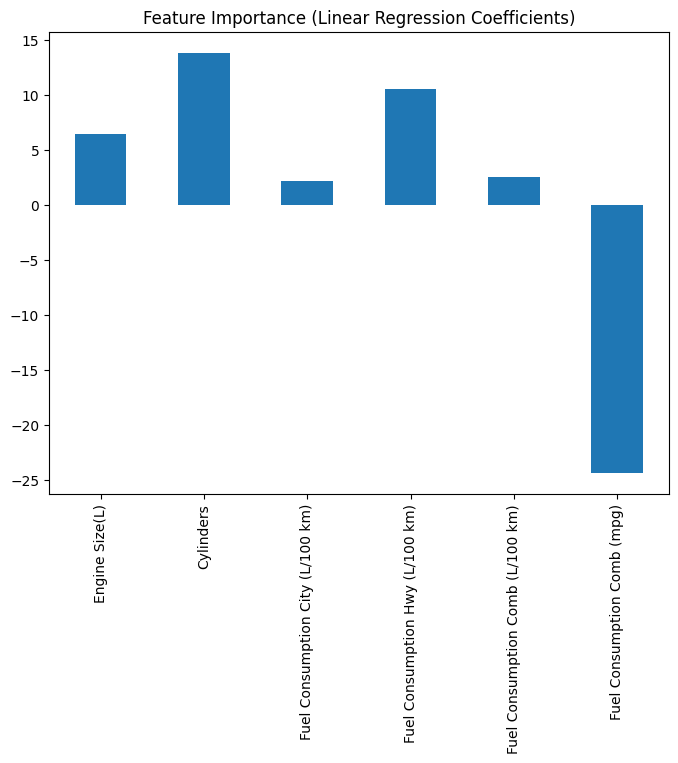

In [12]:
#Now we visualize the importance of features using Linear Regression coefficients.

coefficients = pd.Series(lin_reg.coef_, index=features)
plt.figure(figsize=(8, 6))
coefficients.plot(kind='bar')
plt.title("Feature Importance (Linear Regression Coefficients)")
plt.show()

As per the results we can see the most important feature or most relevant are the number of cylinders.